# Smart Grid Stability Classifier
### Predicting Electrical Grid Stability Using Machine Learning

**Dataset:** Electrical Grid Stability Simulated Data — UCI Machine Learning Repository  
**Task:** Binary Classification (stable / unstable)  
**Models:** Random Forest vs XGBoost  
**Author:** Rafa


In [2]:
pip install xgboost


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.8/101.7 MB 2.6 MB/s eta 0:00:40
    --------------------------------------- 1.8/101.7 MB 3.9 MB/s eta 0:00:26
   - -------------------------------------- 3.7/101.7 MB 5.2 MB/s eta 0:00:19
   -- ------------------------------------- 5.2/101.7 MB 5.7 MB/s eta 0:00:17
   -- ------------------------------------- 7.6/101.7 MB 6.7 MB/s eta 0:00:15
   --- ------------------------------------ 9.2/101.7 MB 7.0 MB/s eta 0:00:14
   ---- ----------------------------------- 11.3/101.7 MB 7.3 MB/s eta 0:00:13
   ---- ----------------------------------- 12.6/101.7 MB 7.1 MB/s eta 0:00:13
   ----- ---------------------------------- 14.9/101.7 MB 7.6 MB/s eta 0:00:12
   ------ --------------------------------- 17.6/101.7 MB 8.1 MB/s eta 0:00:11
   

---
## 1. Imports and Setup

We start by importing all the libraries we need for data processing, visualization, and machine learning.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                              confusion_matrix, roc_auc_score, roc_curve)
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 5)
print("All libraries imported successfully.")

All libraries imported successfully.


---
## 2. Load and Explore the Data

We load the dataset and take a first look at its structure, shape, and basic statistics.  
The dataset contains **10,000 rows** representing different configurations of a 4-node smart grid.  
Each row has **12 input features** (tau, p, g values for 4 nodes) and **1 target column** (stabf).


In [4]:
df = pd.read_csv('Data_for_UCI_named.csv')

print("Shape:", df.shape)
print()
print("Columns:", df.columns.tolist())
print()
print("First 5 rows:")
df.head()

Shape: (10000, 14)

Columns: ['tau1', 'tau2', 'tau3', 'tau4', 'p1', 'p2', 'p3', 'p4', 'g1', 'g2', 'g3', 'g4', 'stab', 'stabf']

First 5 rows:


,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab,stabf
0,2.959060,3.079885,8.381025,9.780754,3.763085,-0.782604,-1.257395,-1.723086,0.650456,0.859578,0.887445,0.958034,0.055347,unstable
1,9.304097,4.902524,3.047541,1.369357,5.067812,-1.940058,-1.872742,-1.255012,0.413441,0.862414,0.562139,0.781760,-0.005957,stable
2,8.971707,8.848428,3.046479,1.214518,3.405158,-1.207456,-1.277210,-0.920492,0.163041,0.766689,0.839444,0.109853,0.003471,unstable
3,0.716415,7.669600,4.486641,2.340563,3.963791,-1.027473,-1.938944,-0.997374,0.446209,0.976744,0.929381,0.362718,0.028871,unstable
4,3.134112,7.608772,4.943759,9.857573,3.525811,-1.125531,-1.845975,-0.554305,0.797110,0.455450,0.656947,0.820923,0.049860,unstable


In [5]:
print("Data Types:")
print(df.dtypes)
print()
print("Missing Values:")
print(df.isnull().sum())
print()
print("Total missing:", df.isnull().sum().sum())

Data Types:
tau1     float64
tau2     float64
tau3     float64
tau4     float64
p1       float64
p2       float64
p3       float64
p4       float64
g1       float64
g2       float64
g3       float64
g4       float64
stab     float64
stabf        str
dtype: object

Missing Values:
tau1     0
tau2     0
tau3     0
tau4     0
p1       0
p2       0
p3       0
p4       0
g1       0
g2       0
g3       0
g4       0
stab     0
stabf    0
dtype: int64

Total missing: 0


In [6]:
print("Basic Statistics:")
df.describe().round(3)

Basic Statistics:


,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab
count,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000
mean,5.250,5.250,5.250,5.250,3.750,-1.250,-1.250,-1.250,0.525,0.525,0.525,0.525,0.016
std,2.743,2.743,2.743,2.743,0.752,0.433,0.433,0.433,0.274,0.274,0.274,0.274,0.037
min,0.501,0.500,0.501,0.500,1.583,-2.000,-2.000,-2.000,0.050,0.050,0.050,0.050,-0.081
25%,2.875,2.875,2.876,2.875,3.218,-1.625,-1.625,-1.625,0.288,0.288,0.288,0.287,-0.016
50%,5.250,5.250,5.250,5.250,3.751,-1.250,-1.250,-1.250,0.525,0.525,0.525,0.525,0.017
75%,7.625,7.625,7.625,7.625,4.282,-0.875,-0.875,-0.875,0.762,0.762,0.762,0.762,0.045
max,9.999,10.000,9.999,9.999,5.864,-0.500,-0.500,-0.500,1.000,1.000,1.000,1.000,0.109


---
## 3. Target Variable Analysis

Our target is **stabf** — whether the grid configuration is stable or unstable.  
We check the class distribution to understand if there is any imbalance between the two classes.


Target Distribution:
stabf
unstable    6380
stable      3620
Name: count, dtype: int64

Percentage:
stabf
unstable    63.8
stable      36.2
Name: proportion, dtype: float64


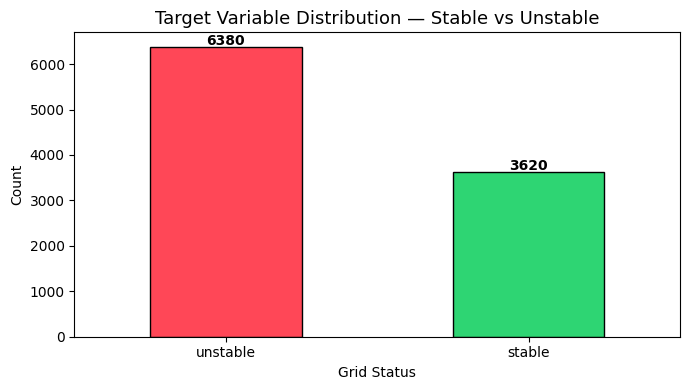

In [7]:
print("Target Distribution:")
print(df['stabf'].value_counts())
print()
print("Percentage:")
print(df['stabf'].value_counts(normalize=True).round(3) * 100)

fig, ax = plt.subplots(figsize=(7, 4))
df['stabf'].value_counts().plot(kind='bar', ax=ax, color=['#ff4757', '#2ed573'],
                                 edgecolor='black', width=0.5)
ax.set_title('Target Variable Distribution — Stable vs Unstable', fontsize=13)
ax.set_xlabel('Grid Status')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=0)
for i, v in enumerate(df['stabf'].value_counts()):
    ax.text(i, v + 50, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

---
## 4. Exploratory Data Analysis (EDA)

Before building the model we explore the relationships between features and the target.  
This helps us understand which variables are most important and how they differ between stable and unstable grids.


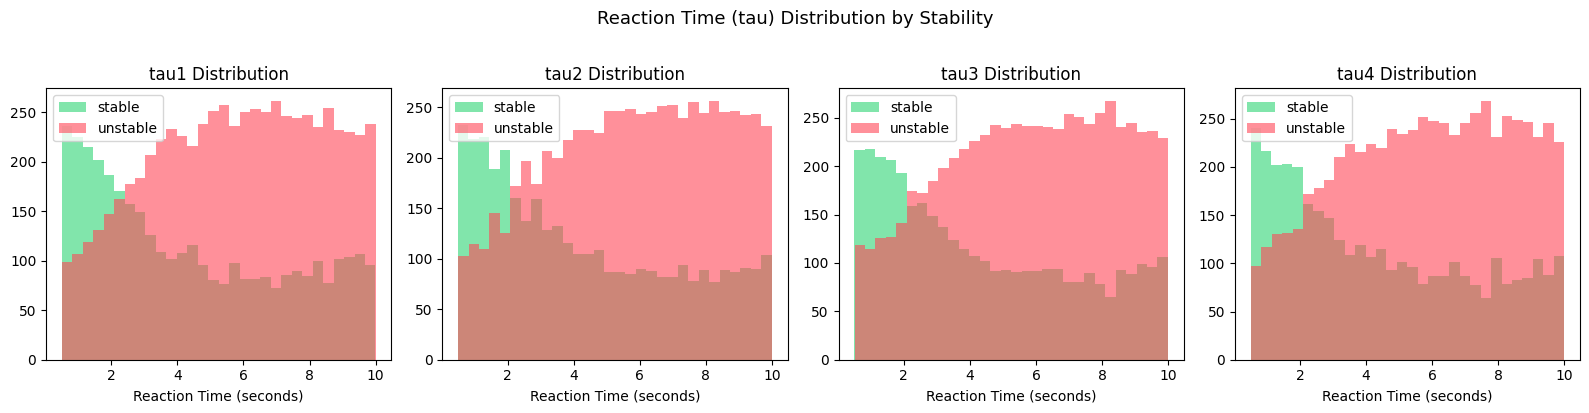

In [8]:
# Distribution of tau values by stability
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
tau_cols = ['tau1', 'tau2', 'tau3', 'tau4']

for i, col in enumerate(tau_cols):
    for label, color in [('stable', '#2ed573'), ('unstable', '#ff4757')]:
        subset = df[df['stabf'] == label][col]
        axes[i].hist(subset, alpha=0.6, label=label, color=color, bins=30, edgecolor='none')
    axes[i].set_title(f'{col} Distribution')
    axes[i].set_xlabel('Reaction Time (seconds)')
    axes[i].legend()

plt.suptitle('Reaction Time (tau) Distribution by Stability', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

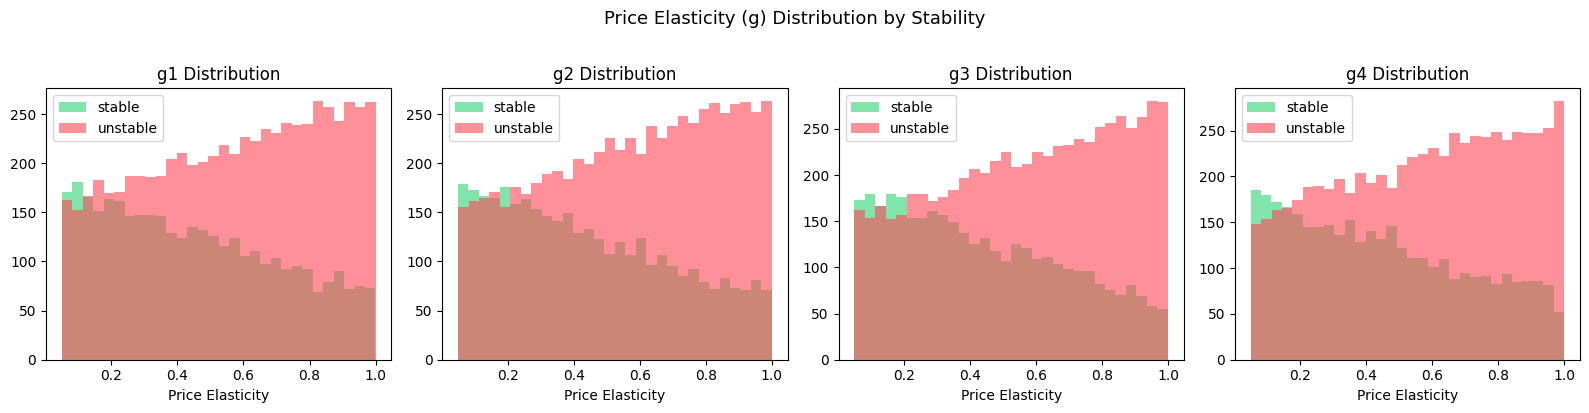

In [9]:
# Distribution of g values by stability
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
g_cols = ['g1', 'g2', 'g3', 'g4']

for i, col in enumerate(g_cols):
    for label, color in [('stable', '#2ed573'), ('unstable', '#ff4757')]:
        subset = df[df['stabf'] == label][col]
        axes[i].hist(subset, alpha=0.6, label=label, color=color, bins=30, edgecolor='none')
    axes[i].set_title(f'{col} Distribution')
    axes[i].set_xlabel('Price Elasticity')
    axes[i].legend()

plt.suptitle('Price Elasticity (g) Distribution by Stability', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

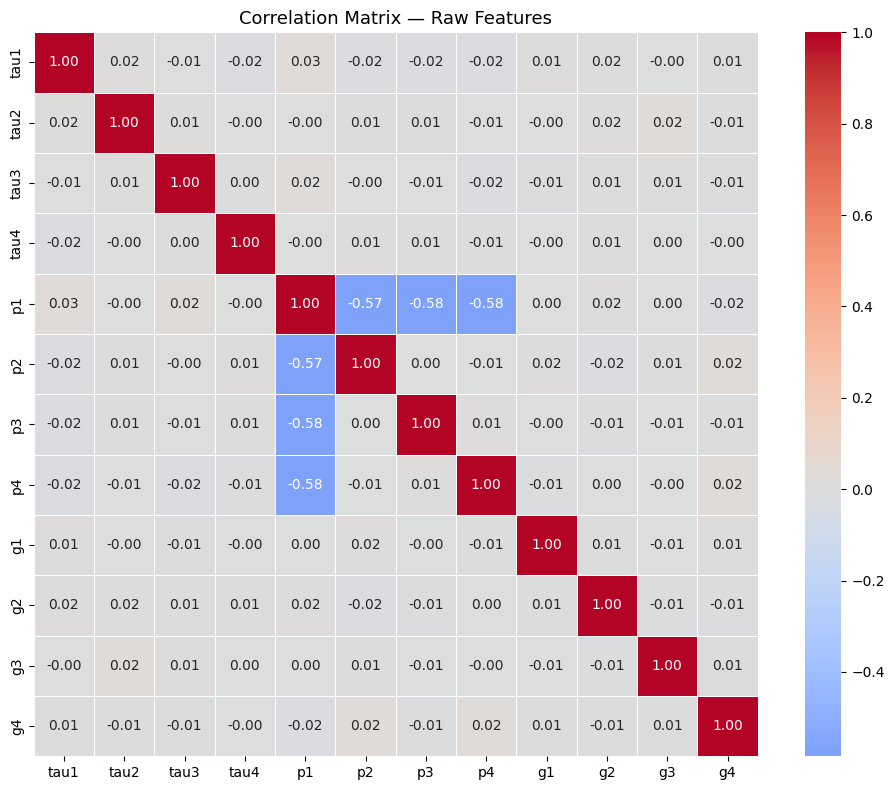

In [10]:
# Correlation heatmap — raw features only (drop stab to avoid leakage)
raw_features = ['tau1','tau2','tau3','tau4','p1','p2','p3','p4','g1','g2','g3','g4']
corr = df[raw_features].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title('Correlation Matrix — Raw Features', fontsize=13)
plt.tight_layout()
plt.show()

In [11]:
# Mean values of features grouped by stability
print("Mean feature values by stability class:")
df.groupby('stabf')[raw_features].mean().round(3)

Mean feature values by stability class:


,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4
stabf,,,,,,,,,,,,
stable,4.395,4.353,4.385,4.378,3.740,-1.254,-1.25,-1.237,0.453,0.446,0.441,0.450
unstable,5.735,5.759,5.741,5.744,3.756,-1.248,-1.25,-1.257,0.566,0.570,0.573,0.567


---
## 5. Data Preprocessing

Before engineering features we prepare the data:

1. **Drop the `stab` column** — this is the numerical form of the target. Using it would be data leakage.
2. **Encode the target** — convert stable/unstable text labels to 0/1 numbers.
3. **Keep p1** — although p1 = |p2+p3+p4| mathematically, we keep it for now and let feature selection handle it.


In [ ]:
# Drop stab — it IS the target in numerical form (data leakage)
df_clean = df.drop(columns=['stab']).copy()

# Encode target: stable=0, unstable=1
le = LabelEncoder()
df_clean['target'] = le.fit_transform(df_clean['stabf'])

print("Label encoding:")
for i, cls in enumerate(le.classes_):
    print(f"  {cls} → {i}")

print()
print("Shape after preprocessing:", df_clean.shape)

---
## 6. Feature Engineering

The raw 12 features describe individual node measurements.  
We engineer 6 new features that capture **system-level patterns** — things the raw values alone cannot express.

These features are grounded in the physics of the Decentral Smart Grid Control (DSGC) system  
and are supported by published research (Scientific Reports, 2026; Symmetry, 2023).

| Feature | Formula | Physical Meaning |
|---|---|---|
| total_reaction_time | tau1+tau2+tau3+tau4 | Overall system sluggishness |
| reaction_time_variance | var(tau1..tau4) | Coordination between nodes |
| producer_consumer_ratio | tau1 / mean(tau2,tau3,tau4) | Producer vs consumer speed gap |
| avg_price_elasticity | mean(g1..g4) | Overall self-correction ability |
| net_power_balance | p1+p2+p3+p4 | Supply vs demand mismatch |
| tau1_x_g1 | tau1 * (1 - g1) | Combined producer risk score |


In [ ]:
# Feature 1: Total reaction time — overall system sluggishness
df_clean['total_reaction_time'] = df_clean['tau1'] + df_clean['tau2'] + df_clean['tau3'] + df_clean['tau4']
print("Feature 1 created: total_reaction_time")
print(df_clean['total_reaction_time'].describe().round(3))

In [ ]:
# Feature 2: Reaction time variance — coordination between nodes
df_clean['reaction_time_variance'] = df_clean[['tau1','tau2','tau3','tau4']].var(axis=1)
print("Feature 2 created: reaction_time_variance")
print(df_clean['reaction_time_variance'].describe().round(3))

In [ ]:
# Feature 3: Producer-consumer ratio — is the producer much slower than consumers?
avg_consumer_tau = (df_clean['tau2'] + df_clean['tau3'] + df_clean['tau4']) / 3
df_clean['producer_consumer_ratio'] = df_clean['tau1'] / avg_consumer_tau
print("Feature 3 created: producer_consumer_ratio")
print(df_clean['producer_consumer_ratio'].describe().round(3))

In [ ]:
# Feature 4: Average price elasticity — overall grid responsiveness
df_clean['avg_price_elasticity'] = (df_clean['g1'] + df_clean['g2'] + df_clean['g3'] + df_clean['g4']) / 4
print("Feature 4 created: avg_price_elasticity")
print(df_clean['avg_price_elasticity'].describe().round(3))

In [ ]:
# Feature 5: Net power balance — supply vs demand mismatch
df_clean['net_power_balance'] = df_clean['p1'] + df_clean['p2'] + df_clean['p3'] + df_clean['p4']
print("Feature 5 created: net_power_balance")
print(df_clean['net_power_balance'].describe().round(3))

In [ ]:
# Feature 6: tau1 x g1 interaction — combined producer risk
# A producer that is BOTH slow AND unresponsive is the most dangerous combination
df_clean['tau1_x_g1'] = df_clean['tau1'] * (1 - df_clean['g1'])
print("Feature 6 created: tau1_x_g1")
print(df_clean['tau1_x_g1'].describe().round(3))

In [ ]:
# Verify all engineered features
engineered = ['total_reaction_time','reaction_time_variance','producer_consumer_ratio',
              'avg_price_elasticity','net_power_balance','tau1_x_g1']

print("All 6 engineered features created successfully.")
print()
print("Engineered features — mean by stability class:")
df_clean.groupby('stabf')[engineered].mean().round(3)

In [ ]:
# Visualize engineered features by stability
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, feat in enumerate(engineered):
    for label, color in [('stable', '#2ed573'), ('unstable', '#ff4757')]:
        subset = df_clean[df_clean['stabf'] == label][feat]
        axes[i].hist(subset, alpha=0.6, label=label, color=color, bins=40, edgecolor='none')
    axes[i].set_title(feat)
    axes[i].legend()
    axes[i].set_xlabel('Value')

plt.suptitle('Engineered Features Distribution by Stability', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

---
## 7. Prepare Features and Split Data

We define the full feature set (12 raw + 6 engineered = 18 features total)  
and split the data into **80% training** and **20% testing** sets.  
We use stratified splitting to ensure both sets have the same class ratio.


In [ ]:
feature_cols = [
    # Raw features
    'tau1','tau2','tau3','tau4',
    'p1','p2','p3','p4',
    'g1','g2','g3','g4',
    # Engineered features
    'total_reaction_time','reaction_time_variance','producer_consumer_ratio',
    'avg_price_elasticity','net_power_balance','tau1_x_g1'
]

X = df_clean[feature_cols]
y = df_clean['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Total features: {len(feature_cols)}")
print(f"  Raw features: 12")
print(f"  Engineered features: 6")
print()
print(f"Training set: {X_train.shape[0]} rows")
print(f"Test set:     {X_test.shape[0]} rows")
print()
print(f"Training class distribution:")
print(pd.Series(y_train).value_counts().rename({0:'stable',1:'unstable'}))

---
## 8. Feature Selection — Which Features Matter Most?

We train a quick Random Forest to rank feature importances.  
This tells us which of our 18 features contribute most to predicting stability.  
This step confirms that our engineered features are actually useful.


In [ ]:
# Train a Random Forest for feature importance ranking
rf_fi = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced', n_jobs=-1)
rf_fi.fit(X_train, y_train)

importances = pd.Series(rf_fi.feature_importances_, index=feature_cols).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#ffa502' if f in ['total_reaction_time','reaction_time_variance',
          'producer_consumer_ratio','avg_price_elasticity',
          'net_power_balance','tau1_x_g1'] else '#57606f' for f in importances.index]
importances.plot(kind='barh', ax=ax, color=colors, edgecolor='none')
ax.set_title('Feature Importance — Random Forest\n(Orange = Engineered Features)', fontsize=13)
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()

print("Top 10 most important features:")
print(importances.sort_values(ascending=False).head(10).round(4))

---
## 9. Model Training — Random Forest vs XGBoost

We train and compare two models using **5-fold stratified cross-validation**.  
Cross-validation gives a more reliable estimate of model performance than a single train/test split.

- **Random Forest** — ensemble of decision trees, robust to overfitting
- **XGBoost** — gradient boosting, often achieves higher accuracy

We use `class_weight='balanced'` / `scale_pos_weight` to handle the class imbalance  
(6,380 unstable vs 3,620 stable).


In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Model 1: Random Forest
print("Training Random Forest with 5-fold cross-validation...")
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_f1_scores = cross_val_score(rf, X, y, cv=cv, scoring='f1_weighted', n_jobs=-1)
rf_acc_scores = cross_val_score(rf, X, y, cv=cv, scoring='accuracy', n_jobs=-1)

print(f"Random Forest:")
print(f"  CV F1 Weighted:  {rf_f1_scores.mean():.4f} +/- {rf_f1_scores.std():.4f}")
print(f"  CV Accuracy:     {rf_acc_scores.mean():.4f} +/- {rf_acc_scores.std():.4f}")

In [ ]:
# Model 2: XGBoost
print("Training XGBoost with 5-fold cross-validation...")

# scale_pos_weight handles class imbalance: unstable/stable = 6380/3620
scale = 6380 / 3620

xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1,
    verbosity=0
)

xgb_f1_scores = cross_val_score(xgb_model, X, y, cv=cv, scoring='f1_weighted', n_jobs=-1)
xgb_acc_scores = cross_val_score(xgb_model, X, y, cv=cv, scoring='accuracy', n_jobs=-1)

print(f"XGBoost:")
print(f"  CV F1 Weighted:  {xgb_f1_scores.mean():.4f} +/- {xgb_f1_scores.std():.4f}")
print(f"  CV Accuracy:     {xgb_acc_scores.mean():.4f} +/- {xgb_acc_scores.std():.4f}")

In [ ]:
# Cross-validation comparison
print("=" * 55)
print("MODEL COMPARISON — CROSS VALIDATION")
print("=" * 55)
comparison = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost'],
    'CV F1 Weighted': [rf_f1_scores.mean(), xgb_f1_scores.mean()],
    'CV F1 Std': [rf_f1_scores.std(), xgb_f1_scores.std()],
    'CV Accuracy': [rf_acc_scores.mean(), xgb_acc_scores.mean()],
    'CV Acc Std': [rf_acc_scores.std(), xgb_acc_scores.std()],
}).round(4)
print(comparison.to_string(index=False))

winner = 'Random Forest' if rf_f1_scores.mean() > xgb_f1_scores.mean() else 'XGBoost'
print(f"\nWinner based on F1 Weighted: {winner}")

# Bar chart comparison
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(2)
width = 0.35
bars1 = ax.bar(x - width/2, [rf_f1_scores.mean(), xgb_f1_scores.mean()],
               width, label='F1 Weighted', color=['#2ed573','#1e90ff'], edgecolor='black')
bars2 = ax.bar(x + width/2, [rf_acc_scores.mean(), xgb_acc_scores.mean()],
               width, label='Accuracy', color=['#7bed9f','#70a1ff'], edgecolor='black')
ax.set_xticks(x)
ax.set_xticklabels(['Random Forest', 'XGBoost'])
ax.set_ylabel('Score')
ax.set_title('Model Comparison — Cross Validation Results')
ax.legend()
ax.set_ylim(0.85, 1.01)
for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

---
## 10. Final Evaluation on Test Set

We train both models on the full training set and evaluate them on the held-out test set.  
This gives us the final performance metrics.

**Key metric: Recall on the unstable class** — it is more dangerous to miss an unstable prediction  
(the grid collapses with no warning) than to have a false alarm (unnecessary but harmless intervention).


In [ ]:
# Train both models on full training set
rf.fit(X_train, y_train)
xgb_model.fit(X_train, y_train)

class_names = le.classes_  # ['stable', 'unstable']

for name, model in [('Random Forest', rf), ('XGBoost', xgb_model)]:
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    print("=" * 55)
    print(f"{name} — Test Set Results")
    print("=" * 55)
    print(f"Accuracy:         {accuracy_score(y_test, y_pred):.4f}")
    print(f"F1 Weighted:      {f1_score(y_test, y_pred, average='weighted'):.4f}")
    print(f"ROC-AUC:          {roc_auc_score(y_test, y_proba):.4f}")
    print()
    print(classification_report(y_test, y_pred, target_names=class_names))

In [ ]:
# Confusion matrices side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (name, model) in zip(axes, [('Random Forest', rf), ('XGBoost', xgb_model)]):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_title(f'Confusion Matrix — {name}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

In [ ]:
# ROC curves
fig, ax = plt.subplots(figsize=(8, 6))

for name, model, color in [('Random Forest', rf, '#2ed573'), ('XGBoost', xgb_model, '#1e90ff')]:
    y_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    ax.plot(fpr, tpr, color=color, linewidth=2, label=f'{name} (AUC = {auc:.4f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Baseline')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — Random Forest vs XGBoost')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 11. Metrics Summary and Success Criteria

We evaluate whether the model meets the success criteria defined in the README.

| Criterion | Success Threshold | Failure Threshold |
|---|---|---|
| CV F1 Weighted | >= 0.90 | < 0.75 |
| Test Accuracy | >= 0.88 | < 0.75 |
| Test F1 Weighted | >= 0.88 | < 0.75 |
| Unstable Class Recall | >= 0.90 | < 0.80 |
| ROC-AUC | >= 0.92 | < 0.80 |
| Beats baseline (63.8%) | Yes — by 20+ points | No improvement |


In [ ]:
# Final metrics summary
best_model = rf if rf_f1_scores.mean() > xgb_f1_scores.mean() else xgb_model
best_name = 'Random Forest' if rf_f1_scores.mean() > xgb_f1_scores.mean() else 'XGBoost'
best_cv_f1 = max(rf_f1_scores.mean(), xgb_f1_scores.mean())

y_pred_best = best_model.predict(X_test)
y_proba_best = best_model.predict_proba(X_test)[:, 1]

test_acc = accuracy_score(y_test, y_pred_best)
test_f1 = f1_score(y_test, y_pred_best, average='weighted')
test_auc = roc_auc_score(y_test, y_proba_best)

# Recall on unstable class (class index 1)
report = classification_report(y_test, y_pred_best, target_names=class_names, output_dict=True)
unstable_recall = report['unstable']['recall']

baseline_acc = 0.638  # majority class classifier

print("=" * 60)
print(f"BEST MODEL: {best_name}")
print("=" * 60)

criteria = [
    ("CV F1 Weighted",        best_cv_f1,       0.90, 0.75),
    ("Test Accuracy",         test_acc,          0.88, 0.75),
    ("Test F1 Weighted",      test_f1,           0.88, 0.75),
    ("Unstable Class Recall", unstable_recall,   0.90, 0.80),
    ("ROC-AUC",               test_auc,          0.92, 0.80),
]

for name_c, value, success, failure in criteria:
    if value >= success:
        status = "PASS"
    elif value >= failure:
        status = "BORDERLINE"
    else:
        status = "FAIL"
    print(f"  {name_c:<28} {value:.4f}   [{status}]")

print()
improvement = (test_acc - baseline_acc) * 100
print(f"  Baseline accuracy (majority class): {baseline_acc:.3f}")
print(f"  Model accuracy:                     {test_acc:.4f}")
print(f"  Improvement over baseline:          +{improvement:.1f} percentage points")
print(f"  Beats baseline by 20+ points:       {'PASS' if improvement >= 20 else 'FAIL'}")

---
## 12. Sample Prediction with Confidence Score

We demonstrate how the model would be used in a real deployment scenario.  
Given 12 grid parameter values, the model returns a prediction (stable/unstable)  
and a confidence score (the percentage of trees that voted for that prediction).


In [ ]:
# Take a few real samples from the test set and show predictions

print("Sample Predictions from Test Set")
print("=" * 70)

sample_indices = [0, 5, 10, 15, 20]
for idx in sample_indices:
    sample = X_test.iloc[[idx]]
    true_label = class_names[y_test.iloc[idx]]
    pred_label = class_names[best_model.predict(sample)[0]]
    confidence = best_model.predict_proba(sample).max() * 100

    status = "CORRECT" if true_label == pred_label else "WRONG"
    print(f"Sample {idx:>4} | True: {true_label:<10} | Predicted: {pred_label:<10} | "
          f"Confidence: {confidence:.1f}%  [{status}]")

In [ ]:
# Show decision thresholds in action
print("Decision Threshold System")
print("=" * 60)

y_proba_all = best_model.predict_proba(X_test)[:, 1]  # probability of UNSTABLE

above_80  = (y_proba_all >= 0.80).sum()
between_60_80 = ((y_proba_all >= 0.60) & (y_proba_all < 0.80)).sum()
stable_above_75 = ((1 - y_proba_all) >= 0.75).sum()
stable_below_75 = ((1 - y_proba_all) < 0.75).sum()

print(f"UNSTABLE > 80% confidence:         {above_80:>5} cases → Immediate automated action")
print(f"UNSTABLE 60-80% confidence:        {between_60_80:>5} cases → Warning, monitor closely")
print(f"STABLE > 75% confidence:           {stable_above_75:>5} cases → Normal operation")
print(f"STABLE < 75% confidence:           {stable_below_75:>5} cases → Flag for monitoring")

---
## 13. Save the Best Model

We save the trained model to disk so it can be loaded by the deployment API and Gradio app  
without needing to retrain from scratch.


In [ ]:
import pickle

model_package = {
    'model': best_model,
    'model_name': best_name,
    'feature_cols': feature_cols,
    'label_encoder': le,
    'class_names': list(class_names),
    'metrics': {
        'cv_f1': float(best_cv_f1),
        'test_accuracy': float(test_acc),
        'test_f1': float(test_f1),
        'roc_auc': float(test_auc),
        'unstable_recall': float(unstable_recall)
    }
}

with open('grid_stability_model.pkl', 'wb') as f:
    pickle.dump(model_package, f)

print(f"Model saved: grid_stability_model.pkl")
print(f"Best model: {best_name}")
print()
print("Final Metrics Summary:")
for k, v in model_package['metrics'].items():
    print(f"  {k}: {v:.4f}")
print()
print("Ready for Phase 2 — Deployment (API + Docker + Gradio)")